In [1]:
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


# Useful imports

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
import zipfile

from sklearn.model_selection   import train_test_split, cross_val_score,RepeatedKFold
from sklearn.linear_model      import LinearRegression,Ridge,Lasso
from sklearn.model_selection   import GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics           import mean_squared_error, r2_score
from sklearn.preprocessing     import StandardScaler 

random_seed = 42


In [ ]:

def backward_feature_selection(
    X,
    y,
    model=None,
    cv=5,
    scoring="neg_root_mean_squared_error", # this is selecting the scoring method of the crossvalidation scores 
    tol=0.0,
    min_features=1,
    verbose=True
):
    """
    Backward feature selection using cross-validation RMSE.

    Parameters
    ----------
    X : pandas DataFrame
        Feature matrix.

    y : pandas Series or DataFrame
        Target variable.

    model : sklearn model, optional
        Model to use. Defaults to LinearRegression().

    cv : int
        Number of cross-validation folds.

    scoring : str
        Scoring metric. For RMSE, use 'neg_root_mean_squared_error'.

    tol : float
        Minimum improvement required to remove a feature.
        Use 0.0 to remove features only when RMSE improves.

    min_features : int
        Minimum number of features to keep.

    verbose : bool
        Whether to print progress.

    Returns
    -------
    selected_features : list
        Final selected feature names.

    history : pandas DataFrame
        RMSE history during feature selection.
    """

    if model is None:
        model = LinearRegression()

    selected_features = list(X.columns)
    history = []

    # Initial model score using all features
    current_scores = cross_val_score(
        model,
        X[selected_features],
        y,
        cv=cv,
        scoring=scoring
    )

    current_rmse = -current_scores.mean()

    history.append({
        "step": 0,
        "removed_feature": None,
        "num_features": len(selected_features),
        "cv_rmse": current_rmse
    })

    if verbose:
        print(f"Starting RMSE with all features: {current_rmse:.4f}")

    step = 1

    while len(selected_features) > min_features:

        rmse_results = []

        # Try removing each feature one at a time
        for feature in selected_features:

            trial_features = [f for f in selected_features if f != feature]

            scores = cross_val_score(
                model,
                X[trial_features],
                y,
                cv=cv,
                scoring=scoring
            )

            trial_rmse = -scores.mean()

            rmse_results.append({
                "feature_removed": feature,
                "cv_rmse": trial_rmse
            })

        results_df = pd.DataFrame(rmse_results)

        # Lower RMSE is better
        best_row = results_df.loc[results_df["cv_rmse"].idxmin()]

        best_feature_to_remove = best_row["feature_removed"]
        best_rmse = best_row["cv_rmse"]

        improvement = current_rmse - best_rmse

        if verbose:
            print(
                f"Step {step}: Try removing '{best_feature_to_remove}' "
                f"→ RMSE: {best_rmse:.4f}, Improvement: {improvement:.4f}"
            )

        # Stop if removing a feature does not improve RMSE enough
        if improvement > tol:
            selected_features.remove(best_feature_to_remove)
            current_rmse = best_rmse

            history.append({
                "step": step,
                "removed_feature": best_feature_to_remove,
                "num_features": len(selected_features),
                "cv_rmse": current_rmse
            })

            step += 1

        else:
            if verbose:
                print("Stopping: removing more features does not improve RMSE.")
            break

    history_df = pd.DataFrame(history)

    

    return selected_features, history_df

In [ ]:
# Download the Ames Housing Dataset from Snyder's web site

# URL to the zip file
zip_url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/ames_housing.zip"

try:
    response = requests.get(zip_url)
    response.raise_for_status()  # Raise an error for bad status codes
    with zipfile.ZipFile(io.BytesIO(response.content)) as zipf:
        zipf.extractall("Ames_Dataset_HW")
    print("Files downloaded and extracted successfully.")
except requests.exceptions.RequestException as e:
    print(f"Error downloading the file: {e}")


DATA_DIR = "Ames_Dataset_HW"

X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")

y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze("columns")
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze("columns")

print("Training and testing datasets loaded successfully.")




def plot_backward_selection_results(history_df):

    history_plot = history_df.copy()

    best_idx = history_plot["cv_rmse"].idxmin()
    best_row = history_plot.loc[best_idx]

    best_num_features = best_row["num_features"]
    best_rmse = best_row["cv_rmse"]

    original_rmse = history_plot["cv_rmse"].iloc[0]

    history_plot["rmse_improvement"] = original_rmse - history_plot["cv_rmse"]

    best_improvement = history_plot.loc[best_idx, "rmse_improvement"]

    plt.figure(figsize=(10, 6))

    plt.plot(
        history_plot["num_features"],
        history_plot["cv_rmse"],
        marker="o",
        label="CV RMSE"
    )

    plt.scatter(
        best_num_features,
        best_rmse,
        s=150,
        label=f"Best RMSE: {best_rmse:.2f}"
    )

    plt.annotate(
        f"Best RMSE = {best_rmse:.2f}\nFeatures = {best_num_features}",
        xy=(best_num_features, best_rmse),
        xytext=(best_num_features + 3, best_rmse + 200),
        arrowprops=dict(arrowstyle="->")
    )

    plt.xlabel("Number of Features")
    plt.ylabel("Cross-Validated RMSE")
    plt.title("Backward Feature Selection: CV RMSE by Number of Features")
    plt.gca().invert_xaxis()
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))

    plt.plot(
        history_plot["num_features"],
        history_plot["rmse_improvement"],
        marker="o",
        label="RMSE Improvement"
    )

    plt.scatter(
        best_num_features,
        best_improvement,
        s=150,
        label=f"Best Model: {best_num_features} features"
    )

    plt.annotate(
        f"Improvement = {best_improvement:.2f}\nFeatures = {best_num_features}",
        xy=(best_num_features, best_improvement),
        xytext=(best_num_features + 3, best_improvement - 150),
        arrowprops=dict(arrowstyle="->")
    )

    plt.xlabel("Number of Features")
    plt.ylabel("RMSE Improvement from Original Model")
    plt.title("Backward Feature Selection: RMSE Improvement")
    plt.gca().invert_xaxis()
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Original CV RMSE: {original_rmse:.2f}")
    print(f"Best CV RMSE: {best_rmse:.2f}")
    print(f"Best number of features: {best_num_features}")
    print(f"Total RMSE improvement: {best_improvement:.2f}")

Files downloaded and extracted successfully.
Training and testing datasets loaded successfully.


Starting RMSE with all features: 31176.2714
Step 1: Try removing 'Misc Val' → RMSE: 30836.5775, Improvement: 339.6939
Step 2: Try removing 'Pool Area' → RMSE: 30777.2746, Improvement: 59.3029
Step 3: Try removing 'Lot Frontage' → RMSE: 30711.0038, Improvement: 66.2708
Step 4: Try removing 'Roof Matl' → RMSE: 30650.6867, Improvement: 60.3171
Step 5: Try removing 'Garage Area' → RMSE: 30599.6121, Improvement: 51.0747
Step 6: Try removing 'Bsmt Half Bath' → RMSE: 30558.1478, Improvement: 41.4643
Step 7: Try removing 'TotRms AbvGrd' → RMSE: 30519.2895, Improvement: 38.8583
Step 8: Try removing 'Utilities' → RMSE: 30481.3471, Improvement: 37.9423
Step 9: Try removing 'Heating' → RMSE: 30453.0600, Improvement: 28.2871
Step 10: Try removing 'Open Porch SF' → RMSE: 30422.8533, Improvement: 30.2067
Step 11: Try removing 'Bedroom AbvGr' → RMSE: 30398.7076, Improvement: 24.1457
Step 12: Try removing 'Full Bath' → RMSE: 30370.3732, Improvement: 28.3344
Step 13: Try removing 'Garage Finish' → RMSE:

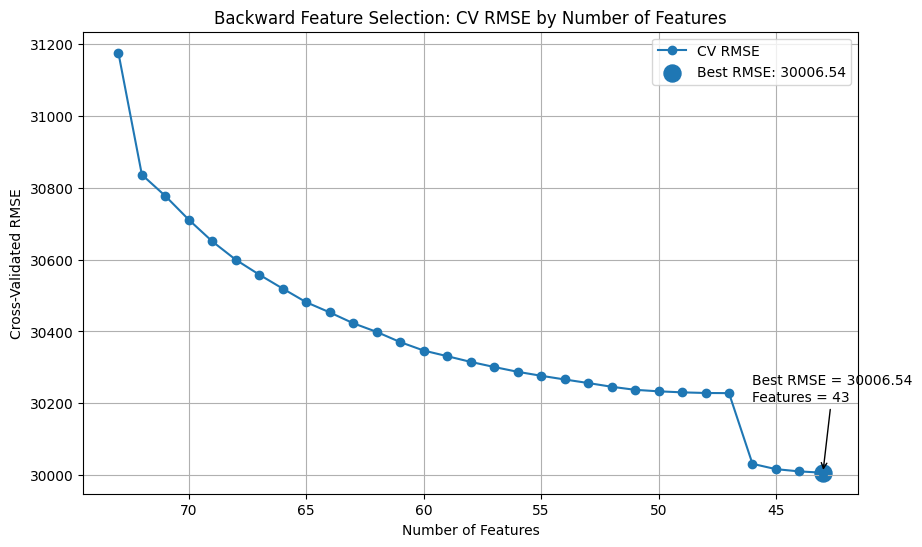

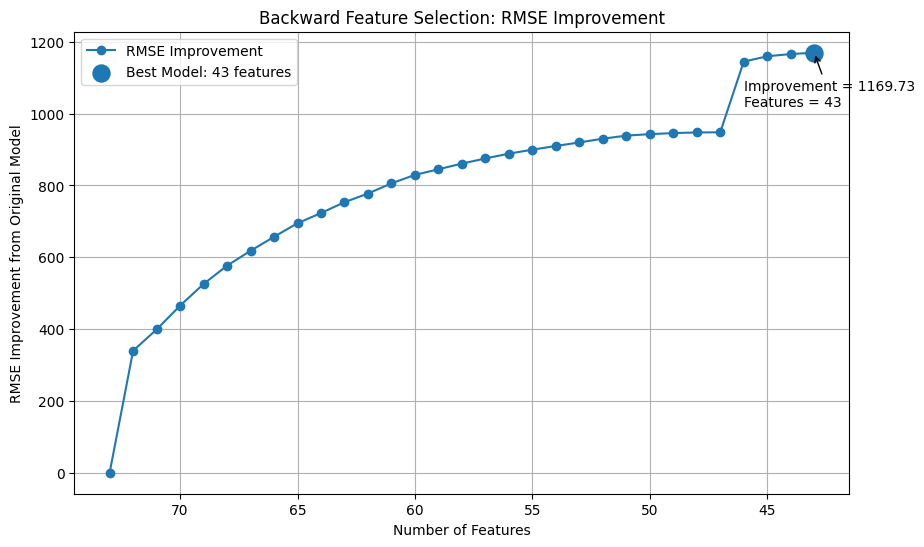

Original CV RMSE: 31176.27
Best CV RMSE: 30006.54
Best number of features: 43
Total RMSE improvement: 1169.73


In [10]:
selected_features, history_df = backward_feature_selection(X_train, y_train)
plot_backward_selection_results(history_df)